In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [6]:
class MyState(TypedDict):
    name: str
    rollno: int
    marks: int

In [22]:
def info(state: MyState) -> MyState:
    name = state["name"]
    rollno = state["rollno"]
    marks = state["marks"]
    return state

In [24]:
def result(state: MyState) -> MyState:
    marks = state["marks"]
    if marks >= 90:
        print("Grade: A")
    elif marks >= 80:
        print("Grade: B")
    elif marks >= 70:
        print("Grade: C")
    else:
        print("Grade: F")
    return state

In [25]:
graph = StateGraph(MyState)
graph.add_node("info", info)
graph.add_node("result",result)
graph.add_edge(START , "info")
graph.add_edge("info", "result")
graph.add_edge("result", END)


In [26]:
workflow = graph.compile()
app = workflow.invoke({"name": "Alice", "rollno": 123, "marks": 95})


Grade: A


In [27]:
print(app)

{'name': 'Alice', 'rollno': 123, 'marks': 95}


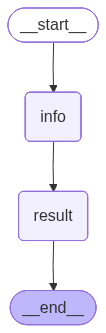

In [28]:
from IPython.display import Image
Image (workflow.get_graph().draw_mermaid_png())
